In [7]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_excel("iris.xlsx")

# Features and target
X = data.iloc[:, :-1]   # sepal_length, sepal_width, petal_length, petal_width
y = data.iloc[:, -1]    # species

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Linear Kernel SVM
# -------------------------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("Linear Kernel SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))

# -------------------------
# RBF Kernel SVM
# -------------------------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("\nRBF Kernel SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rbf))

Linear Kernel SVM
Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

RBF Kernel SVM
Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Accuracy Score: 0.74325

Confusion Matrix:
[[149   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 49 104   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 30   0 103   0   0   0   1   0   0   0   2   0   0   0   1   0   0   0
    0   0   0   0   0   0   0   0]
 [ 43   0   0 113   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 90   0   0   0  51   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 42   0   0   0   0  97   0   0   0   0   0   0   0   0   0   0   0   0
    0   1   0   0   0   0   0   0]
 [ 71   0   0   0   0   0  87   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   0   0   0   0   0]
 [105   0   0   2   0   0   0  33   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [ 21   0   0   0   0   0   0   0 122   0   0   0   0   0   0   0   0   0
    0   0  

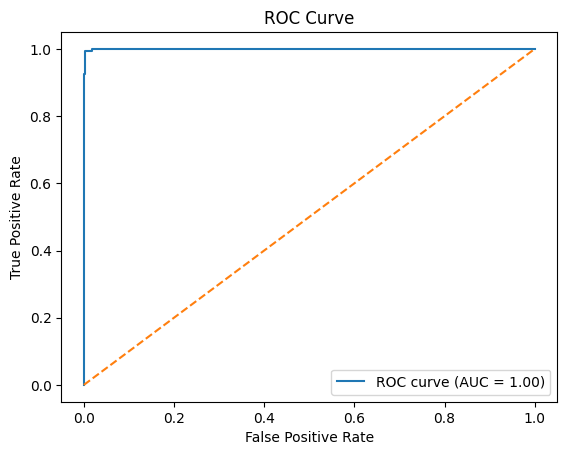


AUC Score: 0.9996775874478694


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Load dataset
data = pd.read_excel("letter-recognition.xlsx")

# Features and target
X = data.iloc[:,1:]
y = data.iloc[:,0]

# Convert labels to binary format (needed for ROC)
classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

# Train SVM model (RBF kernel)
model = OneVsRestClassifier(SVC(kernel='rbf', probability=True))
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Convert back to class labels
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy Score:", accuracy_score(y_test_labels, y_pred_labels))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred_labels))

# ---------------- ROC & AUC ----------------

y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for first class
plt.figure()

plt.plot(fpr[0], tpr[0], label="ROC curve (AUC = %0.2f)" % roc_auc[0])
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("\nAUC Score:", roc_auc[0])